# Flipkart Reviews Sentiment Analysis by using Machine Learning

In [55]:
import re
import nltk
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

In [11]:
df = pd.read_csv(r'https://raw.githubusercontent.com/amankharwal/Website-data/master/flipkart_reviews.csv')
df.head()

,Product_name,Review,Rating
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product_name  2304 non-null   object
 1   Review        2304 non-null   object
 2   Rating        2304 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 54.1+ KB


In [56]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt_tab to C:\Users\ROHIT
[nltk_data]     RANE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\ROHIT
[nltk_data]     RANE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to C:\Users\ROHIT
[nltk_data]     RANE\AppData\Roaming\nltk_data...


True

In [14]:
stemmer = SnowballStemmer('english')

In [69]:
def clean(text):
    corpus = []
    
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = [word for word in text.split(' ') if word not in stopwords.words('english')]
    text = ' '.join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text = ' '.join(text)
    corpus.append(text)
    
    return corpus

In [70]:
clean("Great performance but usually it has also that gaming laptop's issue of battery. It can only stand for 2 - 3 hrs without adapter. So, I prefer that use it with adaptor if you are using any software or playing games.")

['great perform usual also game laptop issu batteri stand    hrs without adapt prefer use adaptor use softwar play game']

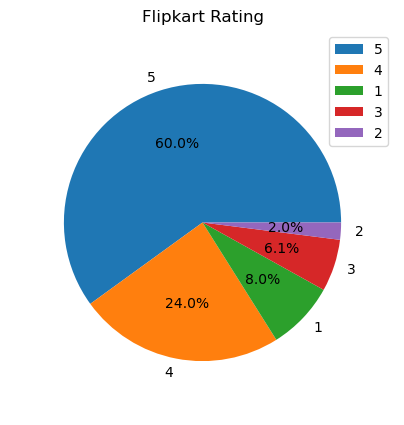

In [71]:
ratings = df['Rating'].value_counts()
numbers = ratings.index
quantity = ratings.values
plt.figure(figsize = (5, 5))
plt.title('Flipkart Rating')
plt.pie(ratings, labels = numbers, radius = 0.9, autopct = '%1.1f%%')
plt.legend()
plt.show()

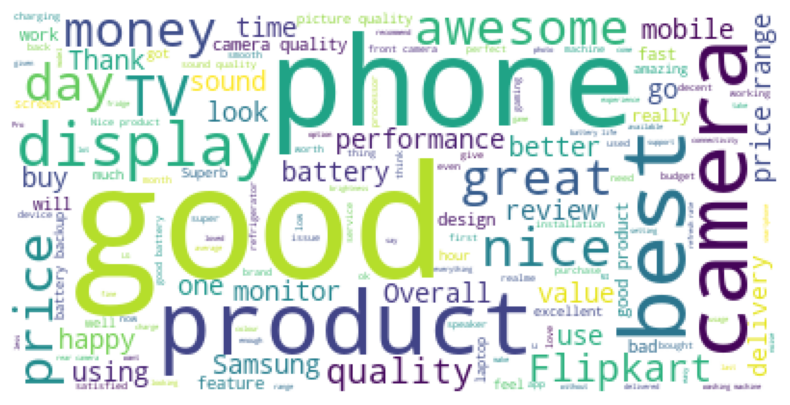

In [72]:
text = ' '.join(i for i in df.Review)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords = stopwords, background_color = 'white').generate(text)
plt.figure(figsize = (12, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [73]:
sentiments = SentimentIntensityAnalyzer()

In [74]:
df['positive'] = [sentiments.polarity_scores(i)['pos'] for i in df['Review']]
df['negative'] = [sentiments.polarity_scores(i)['neg'] for i in df['Review']]
df['neutral'] = [sentiments.polarity_scores(i)['neu'] for i in df['Review']]

In [75]:
flipkart_df = df[['Review', 'positive', 'negative', 'neutral']]

In [76]:
flipkart_df.head()

,Review,positive,negative,neutral
0,Best under 60k Great performanceI got it for a...,0.314,0.073,0.613
1,Good perfomence...,0.744,0.000,0.256
2,Great performance but usually it has also that...,0.119,0.000,0.881
3,My wife is so happy and best product 👌🏻😘,0.568,0.000,0.432
4,"Light weight laptop with new amazing features,...",0.467,0.000,0.533


In [77]:
x = sum(flipkart_df['positive'])
y = sum(flipkart_df['negative'])
z = sum(flipkart_df['neutral'])

In [78]:
def analyze(x, y, z):
    if (x > y) and (x > z):
        print('Positive')
    elif (y > x) and (y > z):
        print('Negative')
    else:
        print('Neutral')

In [79]:
print('Positive: ', x)
print('Negative: ', y)
print('Neutral: ', z)

Positive:  835.67
Negative:  104.917
Neutral:  1363.413


In [80]:
analyze(x, y, z)

Neutral
